# Walmart Store Sales Forecasting — XGBoost

**ლოგირება:** Weights & Biases — პროექტი `walmart-sales-forecasting`, group `XGBoost_Training` (group = „ექსპერიმენტი" ამ არქიტექტურისთვის, შიგნით კი ეტაპების run-ები).

Run-ების სტრუქტურა:

1. `XGBoost_Cleaning` — მონაცემების გაწმენდის გადაწყვეტილებები და მათი ლოგირება
2. `XGBoost_Feature_Engineering` — feature-ების აგება (კალენდარი, დღესასწაულები, ისტორიული აგრეგატები)
3. `XGBoost_Feature_Selection` — importance-ზე დაფუძნებული ფიჩერების შერჩევა
4. `XGBoost_CV_candidate_{i}` — expanding-window time-series CV + ჰიპერპარამეტრების ძებნა (თითო კანდიდატი ცალკე run)
5. `XGBoost_Final_Pipeline` — საბოლოო sklearn **Pipeline**, რომელიც პირდაპირ **raw** test set-ზე ეშვება; ინახება W&B Artifact-ად (type=`model`)

> გაშვების წინაპირობა: Drive-ზე უნდა იდოს raw kaggle ფაილები `MyDrive/ML Final/Data/Raw/walmart-recruiting-store-sales-forecasting/` საქაღალდეში (როგორც `EDA_Preprocessing.ipynb`-ში).

In [1]:
!pip install -q wandb xgboost

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import wandb

wandb.login()  # API key: https://wandb.ai/authorize

WANDB_PROJECT = 'ML-Final'  # გუნდის საერთო პროექტი
GROUP = 'XGBoost_Training'  # "ექსპერიმენტი" ამ არქიტექტურისთვის — ყველა run ამ ჯგუფში ერთიანდება
NB_VERSION = 'v4-no-lag-final'   # XGBoost notebook-ში

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: dshon23 (dshon23-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
import numpy as np
import pandas as pd

BASE = '/content/drive/MyDrive/ML Final/Data/Raw/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(BASE + 'train.csv')
test = pd.read_csv(BASE + 'test.csv')
features = pd.read_csv(BASE + 'features.csv')
stores = pd.read_csv(BASE + 'stores.csv')

for d in (train, test, features):
    d['Date'] = pd.to_datetime(d['Date'])

RAW_COLS = ['Store', 'Dept', 'Date', 'IsHoliday']  # ზუსტად ის სვეტები, რაც raw test.csv-შია
VAL_CUTOFF = '2012-08-17'  # იგივე time split, რაც გუნდმა EDA_Preprocessing-ში გამოიყენა


def wmae(y_true, y_pred, is_holiday):
    """Competition metric: MAE, სადაც სადღესასწაულო კვირებს წონა 5 აქვთ."""
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)


print(train.shape, test.shape, features.shape, stores.shape)

(421570, 5) (115064, 4) (8190, 12) (45, 3)


## Run 1 — Cleaning

აქ ვიმეორებთ და **ვლოგავთ** გუნდის საერთო EDA-ში მიღებულ გადაწყვეტილებებს:
- უარყოფითი `Weekly_Sales` (დაბრუნებები) → 0-ზე იჭრება
- MarkDown1–5-ის NaN → 0 (აქციები უბრალოდ არ იყო) — გამოყენება pipeline-ის შიგნით ხდება
- CPI/Unemployment test პერიოდში ცარიელია → ffill/bfill მაღაზიის მიხედვით — ესეც pipeline-ის შიგნით

In [5]:
MD_COLS = [f'MarkDown{i}' for i in range(1, 6)]

run = wandb.init(project=WANDB_PROJECT, group=GROUP, name='XGBoost_Cleaning',
                 job_type='cleaning',
                 config={'negative_sales_strategy': 'clip_to_zero',
                         'markdown_nan_strategy': 'fill_zero (pipeline-ის შიგნით)',
                         'cpi_unemployment_nan_strategy': 'ffill+bfill per store (pipeline-ის შიგნით)'})

neg_rows = int((train['Weekly_Sales'] < 0).sum())
run.log({
    'raw_train_rows': len(train),
    'raw_test_rows': len(test),
    'negative_sales_rows': neg_rows,
    'markdown_nan_pct': float(features[MD_COLS].isna().mean().mean()),
    'cpi_nan_rows': int(features['CPI'].isna().sum()),
    'unemployment_nan_rows': int(features['Unemployment'].isna().sum()),
})

# გუნდის EDA-ს გადაწყვეტილება, აქ raw მონაცემებზე თავიდან გამოყენებული:
train['Weekly_Sales'] = train['Weekly_Sales'].clip(lower=0)
print('clipped negative rows:', neg_rows)

run.finish()

clipped negative rows: 1285


cpi_nan_rows,▁
markdown_nan_pct,▁
negative_sales_rows,▁
raw_test_rows,▁
raw_train_rows,▁
unemployment_nan_rows,▁
cpi_nan_rows,585
markdown_nan_pct,0.55849
negative_sales_rows,1285
raw_test_rows,115064
raw_train_rows,421570


## WalmartFeatureBuilder — preprocessing როგორც Pipeline-ის ნაწილი

Kaggle-ის test set-ში მხოლოდ `Store, Dept, Date, IsHoliday` სვეტებია და ის preprocessed **არ არის**. დავალება მოითხოვს, რომ საბოლოო მოდელი Pipeline-ად იყოს შენახული და პირდაპირ raw test-ზე ეშვებოდეს — ამიტომ ყველა გარდაქმნა ამ transformer-შია:

- **merge** `stores.csv`-სთან და `features.csv`-სთან (MarkDown → 0, CPI/Unemployment/Temperature/Fuel_Price → ffill/bfill მაღაზიის მიხედვით)
- **კალენდარული ფიჩერები** (Year, Month, Week, Day) + დღესასწაულის ტიპის flag-ები (Super Bowl, Labor Day, Thanksgiving, Christmas)
- **ისტორიული აგრეგატები**, რომლებსაც `fit()` მხოლოდ train-იდან სწავლობს (leakage არ არის):
  - Store-Dept საშუალო / მედიანა / სტდ და ბოლო 8 კვირის საშუალო (სერიის „ამჟამინდელი დონე")
  - week-of-year სეზონური საშუალოები Store-Dept და Dept დონეზე
  - fallback-ები unseen Store-Dept წყვილებისთვის (Dept → global საშუალო)

> რატომ არა კლასიკური lag ფიჩერები? test-ის შორეული კვირებისთვის lag-1/lag-4 sales უბრალოდ არ არსებობს (მომავალია). ისტორიიდან ნასწავლი აგრეგატები კი მთელ ჰორიზონტზე მუშაობს და pipeline-ს raw test-ზე გაშვებადს ხდის.

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

FEATURES_ALL = [
    'Store', 'Dept', 'IsHoliday', 'Type', 'Size',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'Week', 'Day',
    'Holiday_SuperBowl', 'Holiday_LaborDay', 'Holiday_Thanksgiving', 'Holiday_Christmas',
    'Weeks_to_Christmas', 'Weeks_to_Thanksgiving',
    'SD_Mean', 'SD_Median', 'SD_Std', 'SD_Recent_Mean',
    'SD_Week_Mean', 'Dept_Week_Mean', 'Store_Mean', 'Dept_Mean',
]
# შენიშვნა: SD_Lag52/SD_Lag52_Smooth ორ ვერსიაში გაიტესტა (v2: SD_Week_Mean fallback,
# v3: NaN fallback) და ორივე არქიტექტურაზე კონტროლირებადი ablation-ით უარყოფილია:
# SD_Week_Mean უკვე იჭერს სეზონურ სიგნალს 2 წლის საშუალოდ, lag-52 კი იმავე სიგნალის
# ერთი ხმაურიანი დაკვირვებაა — მოდელი მასზე overfit-დებოდა (XGB: 1447 lag-ის გარეშე
# vs 1680 lag-ით; LGBM: 1503 vs 1723).


class WalmartFeatureBuilder(BaseEstimator, TransformerMixin):
    """Raw (Store, Dept, Date, IsHoliday) -> model-ready feature matrix.

    stores.csv/features.csv-ის merge და sales-ისტორიის აგრეგატები transformer-შია,
    ამიტომ fit-ებული pipeline პირდაპირ დაუმუშავებელ test set-ზე ეშვება.
    """

    def __init__(self, stores_df=None, features_df=None, use_columns=None):
        self.stores_df = stores_df
        self.features_df = features_df
        self.use_columns = use_columns

    @staticmethod
    def _holiday_type(date):
        m, d = date.month, date.day
        if m == 2 and 5 <= d <= 12:
            return 'SuperBowl'
        if m == 9 and 4 <= d <= 11:
            return 'LaborDay'
        if m == 11 and 22 <= d <= 29:
            return 'Thanksgiving'
        if m == 12 and 24 <= d <= 31:
            return 'Christmas'
        return 'None'

    def _base_features(self, X):
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])
        df['_row'] = np.arange(len(df))  # merge/sort-ების შემდეგ თავდაპირველი რიგის აღსადგენად
        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left', suffixes=('', '_dup'))
        df = df.loc[:, ~df.columns.str.endswith('_dup')]
        md_cols = [f'MarkDown{i}' for i in range(1, 6)]
        df[md_cols] = df[md_cols].fillna(0)
        df = df.sort_values(['Store', 'Date'])
        for col in ['CPI', 'Unemployment', 'Temperature', 'Fuel_Price']:
            df[col] = df.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['Day'] = df['Date'].dt.day
        htype = df['Date'].apply(self._holiday_type)
        for h in ['SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas']:
            df[f'Holiday_{h}'] = (htype == h).astype(int)
        df['IsHoliday'] = df['IsHoliday'].astype(int)
        df['Type'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})
        # რამდენი კვირაა დარჩენილი წლის მთავარ სავაჭრო პიკებამდე
        df['Weeks_to_Christmas'] = (52 - df['Week']) % 52
        df['Weeks_to_Thanksgiving'] = (47 - df['Week']) % 52
        return df.sort_values('_row').drop(columns='_row').reset_index(drop=True)

    def fit(self, X, y):
        df = self._base_features(X)
        df['Weekly_Sales'] = np.asarray(y)
        self.global_mean_ = df['Weekly_Sales'].mean()
        g = df.groupby(['Store', 'Dept'])['Weekly_Sales']
        self.sd_stats_ = g.agg(SD_Mean='mean', SD_Median='median', SD_Std='std').reset_index()
        self.sd_week_ = (df.groupby(['Store', 'Dept', 'Week'])['Weekly_Sales']
                           .mean().rename('SD_Week_Mean').reset_index())
        self.dept_week_ = (df.groupby(['Dept', 'Week'])['Weekly_Sales']
                             .mean().rename('Dept_Week_Mean').reset_index())
        self.store_mean_ = (df.groupby('Store')['Weekly_Sales']
                              .mean().rename('Store_Mean').reset_index())
        self.dept_mean_ = (df.groupby('Dept')['Weekly_Sales']
                             .mean().rename('Dept_Mean').reset_index())
        last_date = df['Date'].max()
        recent = df[df['Date'] > last_date - pd.Timedelta(weeks=8)]
        self.sd_recent_ = (recent.groupby(['Store', 'Dept'])['Weekly_Sales']
                                 .mean().rename('SD_Recent_Mean').reset_index())
        return self

    def transform(self, X):
        df = self._base_features(X)
        df = (df.merge(self.sd_stats_, on=['Store', 'Dept'], how='left')
                .merge(self.sd_week_, on=['Store', 'Dept', 'Week'], how='left')
                .merge(self.dept_week_, on=['Dept', 'Week'], how='left')
                .merge(self.store_mean_, on='Store', how='left')
                .merge(self.dept_mean_, on='Dept', how='left')
                .merge(self.sd_recent_, on=['Store', 'Dept'], how='left'))
        # fallback-ები: unseen (Store, Dept) წყვილი -> Dept-ის დონე -> global საშუალო
        df['SD_Week_Mean'] = df['SD_Week_Mean'].fillna(df['Dept_Week_Mean'])
        for c in ['SD_Mean', 'SD_Median', 'SD_Recent_Mean']:
            df[c] = df[c].fillna(df['Dept_Mean'])
        df['SD_Std'] = df['SD_Std'].fillna(0)
        for c in ['SD_Week_Mean', 'Dept_Week_Mean', 'Store_Mean', 'Dept_Mean']:
            df[c] = df[c].fillna(self.global_mean_)
        cols = self.use_columns if self.use_columns is not None else FEATURES_ALL
        return df[cols]

## Run 2 — Feature Engineering

ვაშენებთ ფიჩერებს გუნდის საერთო time split-ით (`< 2012-08-17` = train ნაწილი, დანარჩენი = ვალიდაცია). აგრეგატები **მხოლოდ** train ნაწილიდან ისწავლება, რომ ვალიდაციაში leakage არ იყოს.

In [7]:
tr_mask = train['Date'] < VAL_CUTOFF
train_part, val_part = train[tr_mask], train[~tr_mask]

run = wandb.init(project=WANDB_PROJECT, group=GROUP, name='XGBoost_Feature_Engineering',
                 job_type='features',
                 config={'history_aggregates':
                         'SD mean/median/std, recent-8w mean, week-of-year means, store/dept means'})

fb = WalmartFeatureBuilder(stores, features)
X_tr = fb.fit_transform(train_part[RAW_COLS], train_part['Weekly_Sales'])
X_val = fb.transform(val_part[RAW_COLS])
y_tr = train_part['Weekly_Sales'].values
y_val = val_part['Weekly_Sales'].values

run.config.update({'n_features': X_tr.shape[1], 'features': list(X_tr.columns),
                   'features_version': NB_VERSION})
run.log({
    'train_rows': len(X_tr),
    'val_rows': len(X_val),
    'nan_cells_after_transform': int(X_val.isna().sum().sum()),
})
run.finish()

X_tr.head()

nan_cells_after_transform,▁
train_rows,▁
val_rows,▁
nan_cells_after_transform,0
train_rows,388964
val_rows,32606


,Store,Dept,IsHoliday,Type,Size,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,...,Weeks_to_Christmas,Weeks_to_Thanksgiving,SD_Mean,SD_Median,SD_Std,SD_Recent_Mean,SD_Week_Mean,Dept_Week_Mean,Store_Mean,Dept_Mean
0,1,1,0,0,151315,42.31,2.572,211.096358,8.106,0.0,...,47,42,22702.465,18489.485,10192.293865,16446.65625,23366.916667,18475.431704,21727.118507,19302.258939
1,1,1,1,0,151315,38.51,2.548,211.242170,8.106,0.0,...,46,41,22702.465,18489.485,10192.293865,16446.65625,40305.050000,28148.219630,21727.118507,19302.258939
2,1,1,0,0,151315,39.93,2.514,211.289143,8.106,0.0,...,45,40,22702.465,18489.485,10192.293865,16446.65625,47500.506667,32287.171926,21727.118507,19302.258939
3,1,1,0,0,151315,46.63,2.561,211.319643,8.106,0.0,...,44,39,22702.465,18489.485,10192.293865,16446.65625,19630.530000,14847.172074,21727.118507,19302.258939
4,1,1,0,0,151315,46.50,2.625,211.350143,8.106,0.0,...,43,38,22702.465,18489.485,10192.293865,16446.65625,20756.180000,16563.271111,21727.118507,19302.258939


## Run 3 — Feature Selection

სწრაფი probe მოდელით ვითვლით feature importance-ს და ვადარებთ სამ ვარიანტს: top-12, top-18 და ყველა ფიჩერი. შერჩევის კრიტერიუმი — ვალიდაციის WMAE. sample_weight-ად ვიყენებთ WMAE-ს წონებს (holiday კვირა ×5), რომ ტრენინგიც მეტრიკას მიჰყვებოდეს.

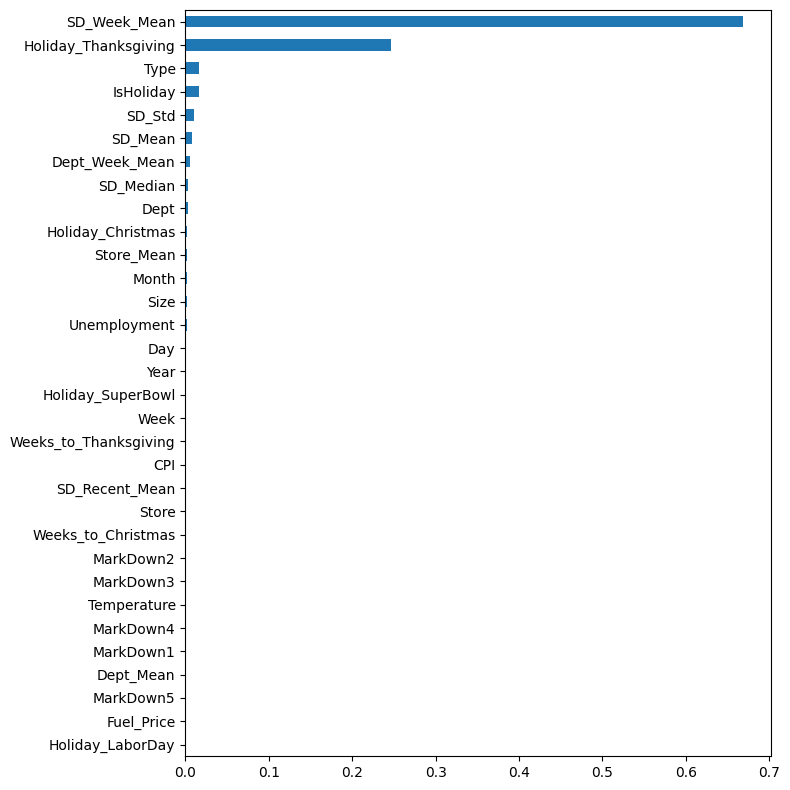

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [00:51:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


top 12 features -> val WMAE 1,885.57
top 18 features -> val WMAE 1,506.92
top 24 features -> val WMAE 1,505.08
top 32 features -> val WMAE 1,521.90


val_wmae_top_12,▁
val_wmae_top_18,▁
val_wmae_top_24,▁
val_wmae_top_32,▁
selected_k,24
val_wmae_top_12,1885.57448
val_wmae_top_18,1506.91662
val_wmae_top_24,1505.08366
val_wmae_top_32,1521.90174


Selected 24 features


In [8]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import shutil

GPU = shutil.which('nvidia-smi') is not None  # GPU runtime-ზე XGBoost ავტომატურად აჩქარდება

BASE_PARAMS = dict(subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                   random_state=42, n_jobs=-1,
                   device='cuda' if GPU else 'cpu')

w_tr = 1 + 4 * X_tr['IsHoliday'].values  # WMAE-ს წონები sample_weight-ად

run = wandb.init(project=WANDB_PROJECT, group=GROUP, name='XGBoost_Feature_Selection',
                 job_type='feature_selection', config={'features_version': NB_VERSION})

probe = XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=8, **BASE_PARAMS)
probe.fit(X_tr, y_tr, sample_weight=w_tr)

imp = pd.Series(probe.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
run.log({'importance_table': wandb.Table(
    dataframe=imp.rename('importance').reset_index().rename(columns={'index': 'feature'}))})

fig, ax = plt.subplots(figsize=(8, 8))
imp.plot.barh(ax=ax)
ax.invert_yaxis()
fig.tight_layout()
run.log({'feature_importances': wandb.Image(fig)})
plt.show()

results = {}
for k in [12, 18, 24, len(imp)]:  # top-8 ორივე წინა გაშვებაში მკვეთრად აგებდა — ამოღებულია
    cols_k = imp.head(k).index.tolist()
    m = XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=8, **BASE_PARAMS)
    m.fit(X_tr[cols_k], y_tr, sample_weight=w_tr)
    score = wmae(y_val, m.predict(X_val[cols_k]), val_part['IsHoliday'].values)
    results[k] = score
    run.log({f'val_wmae_top_{k}': score})
    print(f'top {k:>2} features -> val WMAE {score:,.2f}')

best_k = min(results, key=results.get)
SELECTED_FEATURES = imp.head(best_k).index.tolist()
run.summary['selected_k'] = best_k
run.config['selected_features'] = SELECTED_FEATURES
run.finish()

print('Selected', best_k, 'features')

## Run 4 — Time-Series Cross-Validation + Hyperparameter Search

ჩვეულებრივი (shuffle) K-Fold time-series-ზე leakage-ს იძლევა — მომავლით ვისწავლიდით წარსულს. ამიტომ ვიყენებთ **expanding window** სქემას: 3 fold, თითო ვალიდაციის ფანჯარა ~13 კვირა, train ყოველ ჯერზე იზრდება. თითოეული კანდიდატი ცალკე W&B run-ად ილოგება (job_type=`cv`), რომ პროექტის დაფაზე ადვილად შედარდეს.

In [9]:
CV_FOLDS = [
    ('2011-11-18', '2012-02-17'),
    ('2012-02-17', '2012-05-18'),
    ('2012-05-18', '2012-08-17'),
]

PARAM_GRID = [
    # სამი გაშვების დასკვნები: depth=10 სტაბილურად საუკეთესო; depth=12, MAE objective,
    # min_child_weight — ვერცერთმა ვერ აჯობა. კომპაქტური ფინალური grid:
    {'n_estimators': 500, 'learning_rate': 0.10, 'max_depth': 10},   # ყველა წინა გაშვების საუკეთესო
    {'n_estimators': 800, 'learning_rate': 0.05, 'max_depth': 10},
    {'n_estimators': 500, 'learning_rate': 0.10, 'max_depth': 10, 'min_child_weight': 5},
]


def cv_scores(params):
    scores = []
    for val_start, val_end in CV_FOLDS:
        tr = train[train['Date'] < val_start]
        va = train[(train['Date'] >= val_start) & (train['Date'] < val_end)]
        fb = WalmartFeatureBuilder(stores, features, use_columns=SELECTED_FEATURES)
        X_a = fb.fit_transform(tr[RAW_COLS], tr['Weekly_Sales'])
        X_b = fb.transform(va[RAW_COLS])
        m = XGBRegressor(**{**BASE_PARAMS, **params})
        m.fit(X_a, tr['Weekly_Sales'], sample_weight=1 + 4 * tr['IsHoliday'].astype(int))
        scores.append(wmae(va['Weekly_Sales'], m.predict(X_b), va['IsHoliday']))
    return scores


best_cv, BEST_PARAMS = np.inf, None
for i, params in enumerate(PARAM_GRID):
    run = wandb.init(project=WANDB_PROJECT, group=GROUP, name=f'XGBoost_CV_candidate_{i}',
                     job_type='cv',
                     config={**params, 'cv_scheme': 'expanding window, 3 folds x ~13 weeks',
                             'features_version': NB_VERSION})
    scores = cv_scores(params)
    for j, s in enumerate(scores):
        run.log({'fold': j, 'fold_wmae': s})
    mean_s = float(np.mean(scores))
    run.summary['mean_cv_wmae'] = mean_s
    run.finish()
    print(f'candidate {i}: {params} -> mean CV WMAE {mean_s:,.2f}')
    if mean_s < best_cv:
        best_cv, BEST_PARAMS = mean_s, params

print('Best params:', BEST_PARAMS, f'-> {best_cv:,.2f}')

fold,▁▅█
fold_wmae,█▄▁
fold,2
fold_wmae,1511.09569
mean_cv_wmae,1910.65093


candidate 0: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 10} -> mean CV WMAE 1,910.65


fold,▁▅█
fold_wmae,█▄▁
fold,2
fold_wmae,1516.36242
mean_cv_wmae,1916.81418


candidate 1: {'n_estimators': 800, 'learning_rate': 0.05, 'max_depth': 10} -> mean CV WMAE 1,916.81


fold,▁▅█
fold_wmae,█▄▁
fold,2
fold_wmae,1504.16266
mean_cv_wmae,1913.83965


candidate 2: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5} -> mean CV WMAE 1,913.84
Best params: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 10} -> 1,910.65


## Run 5 — Final Pipeline

საბოლოო მოდელი = `Pipeline(WalmartFeatureBuilder -> XGBoost)`.

1. ჯერ ვაფასებთ გუნდის საერთო holdout split-ზე (`val_wmae` — ამით ვადარებთ არქიტექტურებს ერთმანეთს)
2. შემდეგ ვაფიტებთ **მთელ** train-ზე და ისე ვინახავთ W&B Artifact-ად (type=`model`); სერიალიზაცია `cloudpickle`-ით ხდება, რომ `model_inference.ipynb`-მ pipeline კლასის ხელახლა განსაზღვრის გარეშე ჩატვირთოს
3. sanity check: pipeline-ს პირდაპირ **raw** `test.csv`-ზე ვუშვებთ და submission ფაილს ვაგენერირებთ

In [10]:
import cloudpickle

run = wandb.init(project=WANDB_PROJECT, group=GROUP, name='XGBoost_Final_Pipeline',
                 job_type='final_pipeline',
                 config={**BASE_PARAMS, **BEST_PARAMS,
                         'features': SELECTED_FEATURES,
                         'features_version': NB_VERSION,
                         'sample_weight': '1 + 4*IsHoliday (WMAE weights)'})

pipe = Pipeline([
    ('features', WalmartFeatureBuilder(stores, features, use_columns=SELECTED_FEATURES)),
    ('model', XGBRegressor(**{**BASE_PARAMS, **BEST_PARAMS})),
])

# 1) honest holdout შეფასება გუნდის საერთო split-ზე
pipe.fit(train_part[RAW_COLS], train_part['Weekly_Sales'],
         model__sample_weight=1 + 4 * train_part['IsHoliday'].astype(int))
val_pred = pipe.predict(val_part[RAW_COLS])
val_score = wmae(val_part['Weekly_Sales'], val_pred, val_part['IsHoliday'])
run.summary['val_wmae'] = float(val_score)
print(f'Holdout WMAE: {val_score:,.2f}')

# 2) refit მთელ train-ზე — ეს მიდის საბოლოო მოდელად
pipe.fit(train[RAW_COLS], train['Weekly_Sales'],
         model__sample_weight=1 + 4 * train['IsHoliday'].astype(int))

with open('xgboost_pipeline.pkl', 'wb') as f:
    cloudpickle.dump(pipe, f)

artifact = wandb.Artifact('xgboost_pipeline', type='model',
                          description='sklearn Pipeline: WalmartFeatureBuilder -> XGBoost '
                                      '(runs directly on the raw test set)',
                          metadata={'val_wmae': float(val_score), **BEST_PARAMS})
artifact.add_file('xgboost_pipeline.pkl')
run.log_artifact(artifact)

# 3) pipeline პირდაპირ RAW test set-ზე
test_pred = pipe.predict(test[RAW_COLS])
submission = pd.DataFrame({
    'Id': (test['Store'].astype(str) + '_' + test['Dept'].astype(str)
           + '_' + test['Date'].dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': test_pred,
})
submission.to_csv('submission_xgboost.csv', index=False)
sub_art = wandb.Artifact('xgboost_submission', type='submission')
sub_art.add_file('submission_xgboost.csv')
run.log_artifact(sub_art)

run.finish()
submission.head()

Holdout WMAE: 1,451.36


val_wmae,1451.36178


,Id,Weekly_Sales
0,1_1_2012-11-02,40161.148438
1,1_1_2012-11-09,19513.525391
2,1_1_2012-11-16,20051.941406
3,1_1_2012-11-23,21035.541016
4,1_1_2012-11-30,20908.898438


## Run 6 — Ablation ექსპერიმენტები

„რა შველის რეალურად?" — საბოლოო კონფიგურაციიდან თითო კომპონენტს ვთიშავთ და ვზომავთ ეფექტს holdout WMAE-ზე. თითო ცდა ცალკე W&B run-ია (`job_type='ablation'`):

1. **no_sample_weight** — holiday კვირების ×5 წონის გარეშე ტრენინგი: შველის თუ არა მეტრიკის წონების გამეორება ტრენინგში?
2. **log1p_target** — target-ის ლოგარითმული ტრანსფორმაცია: ხშირად ეხმარება skewed განაწილებას, მაგრამ WMAE აბსოლუტურ ერთეულებშია — ვნახოთ
3. **no_history_features** — ისტორიული აგრეგატების (SD_*, Store/Dept საშუალოები) გარეშე, მხოლოდ კალენდარი + გარე ფაქტორები: რამდენს იძლევა სერიის ისტორია?

უარესი შედეგიც ღირებული დასკვნაა — README-ში ზუსტად ეს ცხრილი ჩავა.

In [11]:
def holdout_run(name, features_list=None, use_weights=True):
    """BEST_PARAMS-ით ტრენინგი train_part-ზე ერთი შეცვლილი კომპონენტით; ცალკე wandb run."""
    feats = features_list if features_list is not None else SELECTED_FEATURES
    fb = WalmartFeatureBuilder(stores, features, use_columns=feats)
    X_a = fb.fit_transform(train_part[RAW_COLS], train_part['Weekly_Sales'])
    X_b = fb.transform(val_part[RAW_COLS])
    m = XGBRegressor(**{**BASE_PARAMS, **BEST_PARAMS})
    sw = (1 + 4 * train_part['IsHoliday'].astype(int).values) if use_weights else None
    m.fit(X_a, train_part['Weekly_Sales'].values, sample_weight=sw)
    score = float(wmae(val_part['Weekly_Sales'], m.predict(X_b), val_part['IsHoliday']))

    run = wandb.init(project=WANDB_PROJECT, group=GROUP, name=name, job_type='ablation',
                     config={**BEST_PARAMS, 'n_features': len(feats),
                             'features_version': NB_VERSION, 'sample_weight': use_weights})
    run.summary['val_wmae'] = score
    run.finish()
    print(f'{name}: val WMAE {score:,.2f}')
    return score


# მხოლოდ კალენდარი + გარე ფაქტორები, სერიის ისტორიის გარეშე:
NO_HISTORY = [f for f in FEATURES_ALL
              if not f.startswith(('SD_', 'Store_Mean', 'Dept_Mean', 'Dept_Week_Mean'))]

ablation_results = {
    'baseline (Final_Pipeline)': float(val_score),
    'no_sample_weight': holdout_run('XGBoost_Ablation_no_sample_weight', use_weights=False),
    'no_history_features': holdout_run('XGBoost_Ablation_no_history_features',
                                       features_list=NO_HISTORY),
}

# შედარების ცხრილი README-სთვის (რაც ნაკლებია, მით უკეთესი):
pd.Series(ablation_results).sort_values().rename('val_WMAE').to_frame()

val_wmae,1442.38454


XGBoost_Ablation_no_sample_weight: val WMAE 1,442.38


val_wmae,1754.72852


XGBoost_Ablation_no_history_features: val WMAE 1,754.73


,val_WMAE
no_sample_weight,1442.384536
baseline (Final_Pipeline),1451.361785
no_history_features,1754.728524


In [12]:
# ვინახავთ საუკეთესო pipeline-ის artifact-ის სახელს Drive-ზე, რომ model_inference.ipynb-მ
# ყველა არქიტექტურა შეადაროს და საუკეთესო W&B Model Registry-ში დაალინკოს.
import json, os

reg_path = '/content/drive/MyDrive/ML Final/best_runs.json'
info = json.load(open(reg_path)) if os.path.exists(reg_path) else {}
info['XGBoost'] = {
    'artifact': f'{WANDB_PROJECT}/xgboost_pipeline:latest',
    'val_wmae': float(val_score),
}
with open(reg_path, 'w') as f:
    json.dump(info, f, indent=2)
info

{'XGBoost': {'artifact': 'ML-Final/xgboost_pipeline:latest',
  'val_wmae': 1451.361784955096},
 'LightGBM': {'artifact': 'ML-Final/lightgbm_pipeline:latest',
  'val_wmae': 1723.1713713460977}}

In [13]:
# sanity check: pipeline W&B artifact-იდან ჩამოვტვირთოთ და raw test-ზე გავუშვათ
import cloudpickle, os

api = wandb.Api()
art = api.artifact(f'{WANDB_PROJECT}/xgboost_pipeline:latest')
art_dir = art.download()
with open(os.path.join(art_dir, 'xgboost_pipeline.pkl'), 'rb') as f:
    loaded = cloudpickle.load(f)
print(loaded.predict(test[RAW_COLS].head())[:5])

wandb:   1 of 1 files downloaded.  


[40161.15  19513.525 20051.941 21035.541 20908.898]


## შემდეგი ნაბიჯი

- artifact-ის სახელი და `val_wmae` ჩაიწერა `best_runs.json`-ში Drive-ზე. `model_inference.ipynb`-ში ყველა არქიტექტურა შედარდება და **საუკეთესო** დაილინკება W&B **Model Registry**-ში:
  ```python
  art = api.artifact(f'{WANDB_PROJECT}/xgboost_pipeline:latest')
  art.link('wandb-registry-model/walmart-best-model')   # ან UI-დან: Artifacts -> Link to registry
  ```
  inference-ში კი მოდელი პირდაპირ registry-იდან ჩამოიტვირთება და ისე გამოიძახება `predict`.
- README-სთვის ჩაინიშნეთ: feature selection-ის შედეგი, CV-ის საუკეთესო პარამეტრები, holdout WMAE და Kaggle-ის score.
- ცნობილი გაუმჯობესება (სურვილისამებრ): საშობაო კვირის shift-adjustment — 2010/2011 წლებში შობამდელი პიკი კვირის სხვა დღეს ხვდება; post-processing-ით Kaggle score უმჯობესდება.

In [14]:
MD_COLS = [f'MarkDown{i}' for i in range(1, 6)]

run = wandb.init(project=WANDB_PROJECT, group=GROUP, name='XGBoost_Cleaning',
                 job_type='cleaning',
                 config={'negative_sales_strategy': 'clip_to_zero',
                         'markdown_nan_strategy': 'fill_zero (pipeline-ის შიგნით)',
                         'cpi_unemployment_nan_strategy': 'ffill+bfill per store (pipeline-ის შიგნით)'})

neg_rows = int((train['Weekly_Sales'] < 0).sum())
run.log({
    'raw_train_rows': len(train),
    'raw_test_rows': len(test),
    'negative_sales_rows': neg_rows,
    'markdown_nan_pct': float(features[MD_COLS].isna().mean().mean()),
    'cpi_nan_rows': int(features['CPI'].isna().sum()),
    'unemployment_nan_rows': int(features['Unemployment'].isna().sum()),
})

# გუნდის EDA-ს გადაწყვეტილება, აქ raw მონაცემებზე თავიდან გამოყენებული:
train['Weekly_Sales'] = train['Weekly_Sales'].clip(lower=0)
print('clipped negative rows:', neg_rows)

run.finish()

clipped negative rows: 0


cpi_nan_rows,▁
markdown_nan_pct,▁
negative_sales_rows,▁
raw_test_rows,▁
raw_train_rows,▁
unemployment_nan_rows,▁
cpi_nan_rows,585
markdown_nan_pct,0.55849
negative_sales_rows,0
raw_test_rows,115064
raw_train_rows,421570


In [15]:
from google.colab import files
files.download('wandb_report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>